<a href="https://colab.research.google.com/github/Tejakodela8688/Population-growth-of-model-/blob/main/PopGrow_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ================================================================
# B.Tech Mathematics Mini Project
# Population Growth Model using Leslie Matrix (B7)
# ================================================================

import numpy as np
import sympy as sp
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------
# 1. USER INPUTS / BENCHMARK DATASET
# ------------------------------------------------
# You can change these values for another species.

age_groups = ["Young", "Adult", "Old"]

# Reproduction/Fertility rates
F = np.array([0.0, 1.2, 0.5], dtype=float)

# Survival rates:
# S1 = Young -> Adult
# S2 = Adult -> Old
S = np.array([0.70, 0.80], dtype=float)

# Initial population in each age group
initial_population = np.array([100, 80, 40], dtype=float)

# Number of future time steps
steps = 10


# ------------------------------------------------
# 2. INPUT VALIDATION
# ------------------------------------------------
assert len(F) == 3, "Enter exactly 3 reproduction rates."
assert len(S) == 2, "Enter exactly 2 survival rates."
assert len(initial_population) == 3, \
       "Enter population for exactly 3 age groups."

assert np.all(F >= 0), "Reproduction rates cannot be negative."
assert np.all((S >= 0) & (S <= 1)), \
       "Survival rates must be between 0 and 1."
assert np.all(initial_population >= 0), \
       "Population cannot be negative."


# ------------------------------------------------
# 3. CONSTRUCT LESLIE MATRIX
# ------------------------------------------------
F1, F2, F3 = F
S1, S2 = S

L = np.array([
    [F1, F2, F3],
    [S1, 0,  0 ],
    [0,  S2, 0 ]
], dtype=float)

print("=" * 65)
print("POPULATION GROWTH MODEL — LESLIE MATRIX")
print("=" * 65)

print("\nAge Groups:")
for i, age in enumerate(age_groups):
    print(f"{i+1}. {age}")

print("\nReproduction Rates:")
print(F)

print("\nSurvival Rates:")
print("Young → Adult :", S1)
print("Adult → Old   :", S2)

print("\nLeslie Matrix:")
print(L)


# ------------------------------------------------
# 4. MATHEMATICAL EQUATION
# ------------------------------------------------
print("\nPopulation transition equation:")
print("N(t+1) = L × N(t)")

print("\nInitial Population Vector:")
print(initial_population)


# ------------------------------------------------
# 5. SYMPY CHARACTERISTIC POLYNOMIAL
# ------------------------------------------------
L_sym = sp.Matrix(L)

lambda_symbol = sp.symbols("λ")

char_poly = L_sym.charpoly(lambda_symbol).as_expr()

print("\nCharacteristic Polynomial:")
sp.pprint(char_poly)

print("\nCharacteristic Equation:")
sp.pprint(sp.Eq(char_poly, 0))


# ------------------------------------------------
# 6. EIGENVALUES AND EIGENVECTORS
# ------------------------------------------------
eigenvalues, eigenvectors = np.linalg.eig(L)

print("\nEigenvalues:")
for i, value in enumerate(eigenvalues):
    print(f"λ{i+1} = {value.real:.6f}")


# ------------------------------------------------
# 7. DOMINANT EIGENVALUE
# ------------------------------------------------
dominant_index = np.argmax(eigenvalues.real)

dominant_lambda = eigenvalues[
    dominant_index
].real

dominant_vector = eigenvectors[
    :, dominant_index
].real

# Eigenvectors can have arbitrary sign.
dominant_vector = np.abs(dominant_vector)

# Normalize eigenvector to obtain proportions
stable_distribution = (
    dominant_vector / dominant_vector.sum()
)


# ------------------------------------------------
# 8. POPULATION STATUS
# ------------------------------------------------
tolerance = 1e-8

if dominant_lambda > 1 + tolerance:
    status = "GROWING"
    explanation = "λ > 1 → Population grows in the long term."

elif dominant_lambda < 1 - tolerance:
    status = "DECLINING"
    explanation = "λ < 1 → Population declines in the long term."

else:
    status = "STABLE"
    explanation = "λ = 1 → Population is stable in the long term."


# ------------------------------------------------
# 9. POPULATION PROJECTION
# ------------------------------------------------
history = [initial_population.copy()]

current_population = initial_population.copy()

for t in range(steps):
    # Leslie model:
    # N(t+1) = L × N(t)
    current_population = L @ current_population
    history.append(current_population.copy())

history = np.array(history)

total_population = history.sum(axis=1)


# ------------------------------------------------
# 10. RESULT TABLE
# ------------------------------------------------
result = pd.DataFrame(
    history,
    columns=age_groups
)

result.insert(
    0,
    "Time Step",
    range(steps + 1)
)

result["Total Population"] = total_population


# ------------------------------------------------
# 11. FINAL OUTPUT
# ------------------------------------------------
print("\n" + "=" * 65)
print("FINAL RESULT")
print("=" * 65)

print(f"\nDominant Eigenvalue (λ): {dominant_lambda:.6f}")

print(f"\nPopulation Status: {status}")

print(f"\n{explanation}")

print("\nStable Age Distribution:")

for age, proportion in zip(
    age_groups,
    stable_distribution
):
    print(
        f"{age:10s}: "
        f"{proportion*100:.2f}%"
    )

print("\nPopulation Projection:")
display(result.round(2))

POPULATION GROWTH MODEL — LESLIE MATRIX

Age Groups:
1. Young
2. Adult
3. Old

Reproduction Rates:
[0.  1.2 0.5]

Survival Rates:
Young → Adult : 0.7
Adult → Old   : 0.8

Leslie Matrix:
[[0.  1.2 0.5]
 [0.7 0.  0. ]
 [0.  0.8 0. ]]

Population transition equation:
N(t+1) = L × N(t)

Initial Population Vector:
[100.  80.  40.]

Characteristic Polynomial:
     3                
1.0⋅λ  - 0.84⋅λ - 0.28

Characteristic Equation:
     3                    
1.0⋅λ  - 0.84⋅λ - 0.28 = 0

Eigenvalues:
λ1 = 1.051769
λ2 = -0.627553
λ3 = -0.424216

FINAL RESULT

Dominant Eigenvalue (λ): 1.051769

Population Status: GROWING

λ > 1 → Population grows in the long term.

Stable Age Distribution:
Young     : 46.05%
Adult     : 30.65%
Old       : 23.31%

Population Projection:


,Time Step,Young,Adult,Old,Total Population
0,0,100.00,80.00,40.00,220.00
1,1,116.00,70.00,64.00,250.00
2,2,116.00,81.20,56.00,253.20
3,3,125.44,81.20,64.96,271.60
4,4,129.92,87.81,64.96,282.69
5,5,137.85,90.94,70.25,299.04
6,6,144.26,96.49,72.76,313.51
7,7,152.17,100.98,77.20,330.35
8,8,159.77,106.52,80.78,347.08
9,9,168.22,111.84,85.22,365.27


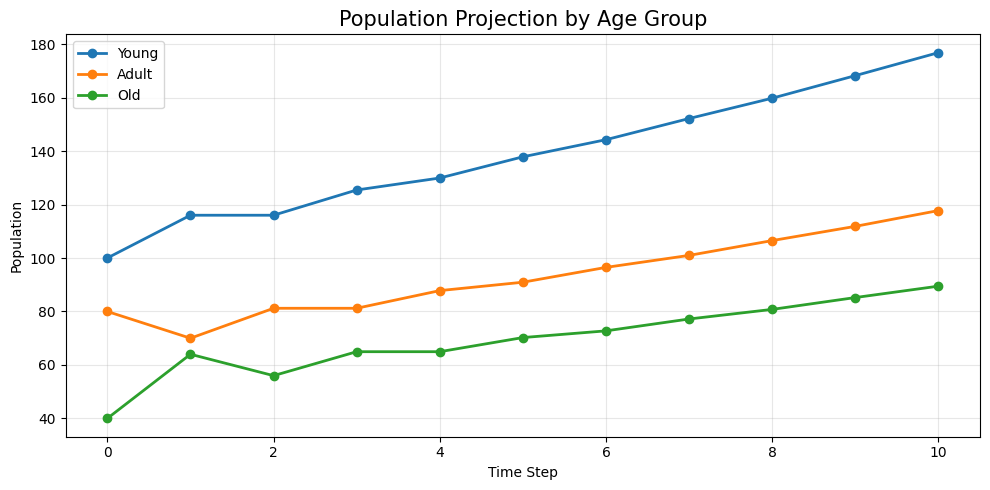

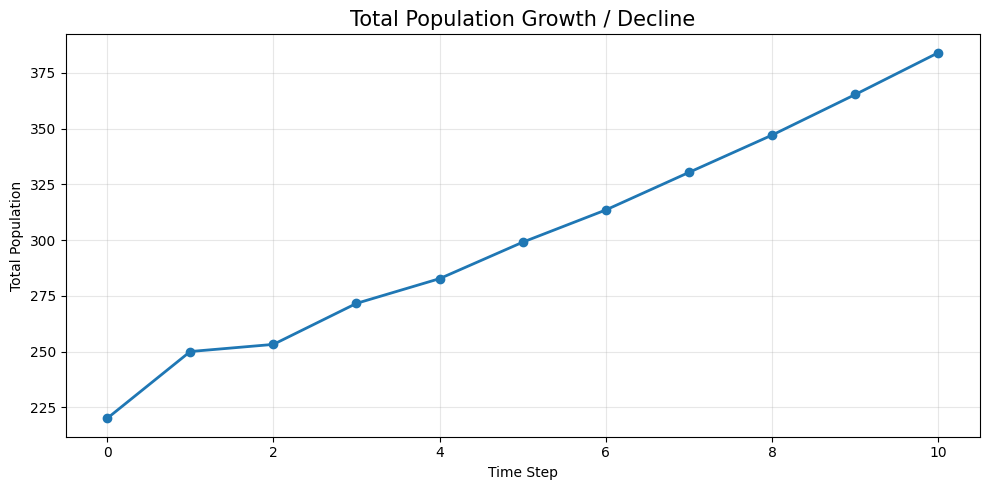

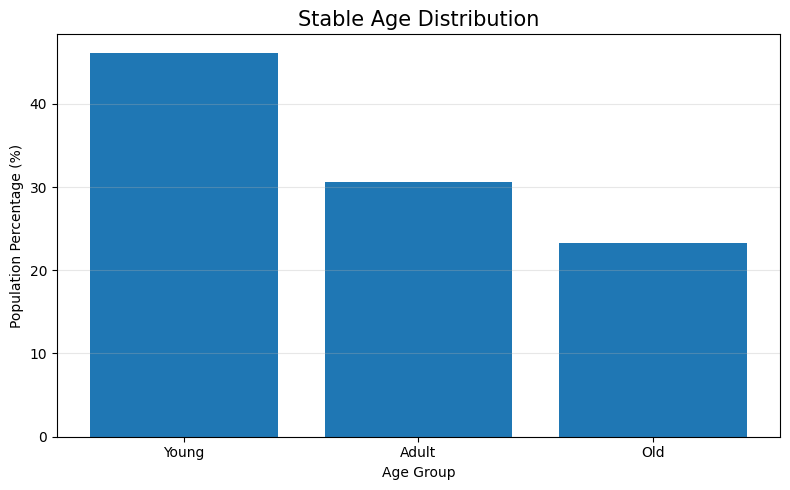

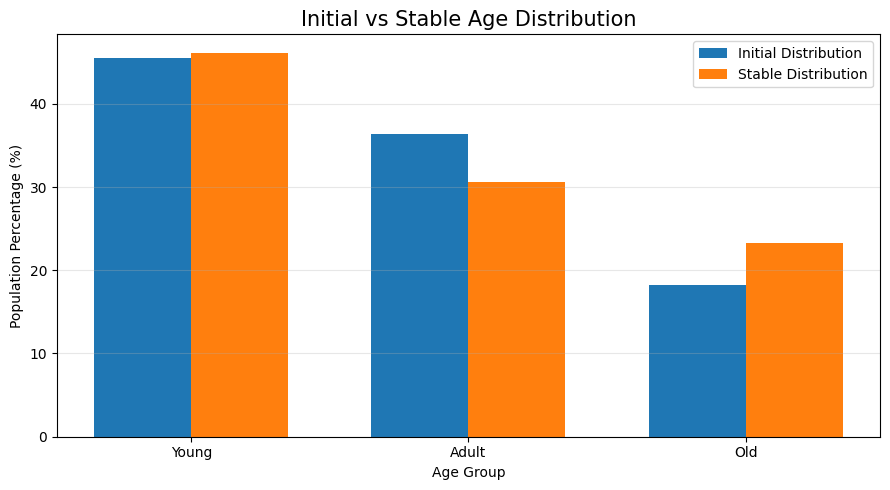



              PROJECT SUMMARY

Project: Population Growth Model (Leslie Matrix)

Leslie Matrix:
[[0.  1.2 0.5]
 [0.7 0.  0. ]
 [0.  0.8 0. ]]

Dominant Eigenvalue λ = 1.051769

Population Status = GROWING

Stable Age Distribution:
  Young: 46.05%
  Adult: 30.65%
  Old: 23.31%

Mathematical Interpretation:
λ > 1, therefore the model predicts long-term population growth.

Key concepts used:
• Leslie Matrix
• Eigenvalues
• Dominant Eigenvalue
• Eigenvectors
• Stable Age Distribution
• Matrix Population Projection

Real-world applications:
• Wildlife conservation
• Population management
• Epidemiology
• Demographic planning


In [ ]:
# ================================================================
# VISUALIZATION AND PROJECT SUMMARY
# ================================================================

# ------------------------------------------------
# CHART 1 — Population by Age Group
# ------------------------------------------------

plt.figure(figsize=(10, 5))

for age in age_groups:
    plt.plot(
        result["Time Step"],
        result[age],
        marker="o",
        linewidth=2,
        label=age
    )

plt.title("Population Projection by Age Group",
          fontsize=15)

plt.xlabel("Time Step")
plt.ylabel("Population")

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# ------------------------------------------------
# CHART 2 — Total Population
# ------------------------------------------------

plt.figure(figsize=(10, 5))

plt.plot(
    result["Time Step"],
    result["Total Population"],
    marker="o",
    linewidth=2
)

plt.title("Total Population Growth / Decline",
          fontsize=15)

plt.xlabel("Time Step")
plt.ylabel("Total Population")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ------------------------------------------------
# CHART 3 — Stable Age Distribution
# ------------------------------------------------

plt.figure(figsize=(8, 5))

plt.bar(
    age_groups,
    stable_distribution * 100
)

plt.title(
    "Stable Age Distribution",
    fontsize=15
)

plt.xlabel("Age Group")
plt.ylabel("Population Percentage (%)")

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()


# ------------------------------------------------
# CHART 4 — Initial vs Stable Distribution
# ------------------------------------------------

initial_distribution = (
    initial_population /
    initial_population.sum()
)

x = np.arange(len(age_groups))
width = 0.35

plt.figure(figsize=(9, 5))

plt.bar(
    x - width/2,
    initial_distribution * 100,
    width,
    label="Initial Distribution"
)

plt.bar(
    x + width/2,
    stable_distribution * 100,
    width,
    label="Stable Distribution"
)

plt.xticks(x, age_groups)

plt.xlabel("Age Group")
plt.ylabel("Population Percentage (%)")

plt.title(
    "Initial vs Stable Age Distribution",
    fontsize=15
)

plt.legend()
plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()


# ------------------------------------------------
# FINAL PROJECT SUMMARY
# ------------------------------------------------

print("\n")
print("=" * 70)
print("              PROJECT SUMMARY")
print("=" * 70)

print("\nProject: Population Growth Model (Leslie Matrix)")

print("\nLeslie Matrix:")
print(L)

print(
    f"\nDominant Eigenvalue λ = "
    f"{dominant_lambda:.6f}"
)

print(f"\nPopulation Status = {status}")

print("\nStable Age Distribution:")

for age, percentage in zip(
    age_groups,
    stable_distribution * 100
):
    print(
        f"  {age}: {percentage:.2f}%"
    )

print("\nMathematical Interpretation:")

if dominant_lambda > 1:
    print(
        "λ > 1, therefore the model predicts "
        "long-term population growth."
    )

elif dominant_lambda < 1:
    print(
        "λ < 1, therefore the model predicts "
        "long-term population decline."
    )

else:
    print(
        "λ = 1, therefore the model predicts "
        "a stable population."
    )

print("\nKey concepts used:")
print("• Leslie Matrix")
print("• Eigenvalues")
print("• Dominant Eigenvalue")
print("• Eigenvectors")
print("• Stable Age Distribution")
print("• Matrix Population Projection")

print("\nReal-world applications:")
print("• Wildlife conservation")
print("• Population management")
print("• Epidemiology")
print("• Demographic planning")

print("=" * 70)